In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

In [3]:
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]
    ),
    transforms.RandomErasing(p=0.5)
])

val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]
    ),
])

batch_size = 256

full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True
)

train_idx, val_idx = torch.utils.data.random_split(
    range(len(full_trainset)), [0.8, 0.2]
)

trainset = torch.utils.data.Subset(
    torchvision.datasets.CIFAR10(root='./data', train=True, transform=train_tf),
    train_idx.indices
)

valset = torch.utils.data.Subset(
    torchvision.datasets.CIFAR10(root='./data', train=True, transform=val_tf),
    val_idx.indices
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True
)
valloader = torch.utils.data.DataLoader(
    valset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=val_tf
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

C:\Users\asmit\PycharmProjects\TorchT\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


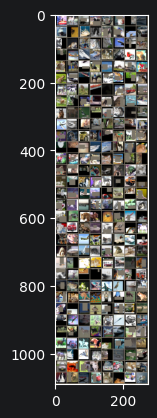

ship  deer  ship  bird  car   cat   bird  ship  plane cat   ship  dog   deer  bird  bird  car   plane frog  dog   cat   deer  plane car   horse cat   plane ship  car   dog   car   truck cat   bird  horse plane horse plane plane car   cat   frog  plane ship  horse car   frog  cat   deer  deer  horse bird  ship  horse cat   truck plane dog   cat   car   truck dog   bird  plane ship  horse dog   bird  horse car   cat   cat   ship  plane ship  cat   plane cat   bird  cat   deer  bird  bird  truck cat   cat   horse horse cat   ship  frog  plane ship  plane dog   car   cat   deer  car   car   cat   cat   ship  bird  frog  dog   cat   dog   dog   plane cat   frog  cat   horse ship  dog   cat   horse cat   truck bird  truck deer  ship  ship  car   deer  cat   bird  car   horse ship  plane truck truck truck cat   plane deer  cat   horse cat   horse plane horse dog   car   frog  ship  truck bird  car   horse dog   frog  plane horse bird  plane car   car   dog   ship  ship  cat   frog  frog  cat 

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)).clip(0, 1))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [5]:
import torch.nn.functional as F
from torch import nn

In [6]:
class SimpleResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(SimpleResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


In [7]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


In [8]:
class Classifier(nn.Module): 
    def __init__(self):
        super(Classifier, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(512, 10)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        return out


In [9]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class Classifier(nn.Module): # ResNet-18
    def __init__(self):
        super(Classifier, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(512, 10)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        return out


In [10]:
classifier = Classifier()

In [11]:
classifier.to(device)

Classifier(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, aff

In [12]:
class EarlyStoping:
    def __init__(self, patience=5, min_delta=0.001, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.best_loss = float('inf')
        self.min_delta = min_delta
        self.counter = 0
        self.early_stop = False

    def __call__(self, loss):
        if loss < self.best_loss - self.min_delta:
            self.best_loss = loss
            self.counter = 0
        else:
            self.counter += 1
            if self.verbose: print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True


In [13]:
from torch import optim

In [14]:
criterion = nn.CrossEntropyLoss()
epochs = 120
optimizer = optim.SGD(classifier.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
# OneCycleLR: max_lr=0.1 for SGD
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)
# Optimization: AMP Scaler
scaler = torch.amp.GradScaler('cuda')


In [15]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            loss = criterion(model(imgs), labels)
            total += loss.item()
    model.train()
    return total / len(loader)

In [16]:
train_losses, val_losses, val_accuracies = [], [], []
import time
epoc_start = time.time()
for epoch in range(epochs):
    classifier.train()
    epoch_loss = 0.0
    n_batches = 0
    start_time = time.time()

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # Optimization: Mixed Precision Forward Pass
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = classifier(inputs)
            loss = criterion(outputs, labels)

        # Optimization: Scaled Backward Pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # OneCycleLR MUST step after every mini-batch, not once per epoch
        scheduler.step()

        epoch_loss += loss.item()
        n_batches += 1

    # ─── Per-epoch logging ───────────────────────────────────────────────────
    avg_train_loss = epoch_loss / n_batches
    train_losses.append(avg_train_loss)

    # Validation: loss + accuracy in one pass
    classifier.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, lbls in valloader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                out = classifier(imgs)
            val_loss += criterion(out, lbls).item()
            _, predicted = torch.max(out, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()

    avg_val_loss = val_loss / len(valloader)
    val_acc = 100.0 * correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    current_lr = scheduler.get_last_lr()[0]
    print(
            f'Epoch [{epoch+1:2d}/{epochs}]  '
            f'Train Loss: {avg_train_loss:.4f}  '
            f'Val Loss: {avg_val_loss:.4f}  '
            f'Val Acc: {val_acc:.2f}%  '
            f'LR: {current_lr:.6f} '
            f'Time: {time.time() - start_time:.2f}s'
          )

print(f"Finished Training in {(time.time() - epoc_start)/60:.2f} minutes")


Epoch [ 1/120]  Train Loss: 1.9633  Val Loss: 1.7433  Val Acc: 38.92%  LR: 0.004183 Time: 17.55s
Epoch [ 2/120]  Train Loss: 1.5964  Val Loss: 1.3263  Val Acc: 52.56%  LR: 0.004729 Time: 4.73s
Epoch [ 3/120]  Train Loss: 1.3912  Val Loss: 1.1500  Val Acc: 59.39%  LR: 0.005636 Time: 4.64s
Epoch [ 4/120]  Train Loss: 1.2626  Val Loss: 1.0418  Val Acc: 63.66%  LR: 0.006896 Time: 4.60s
Epoch [ 5/120]  Train Loss: 1.1524  Val Loss: 1.0876  Val Acc: 63.41%  LR: 0.008499 Time: 4.53s
Epoch [ 6/120]  Train Loss: 1.0604  Val Loss: 0.8905  Val Acc: 70.38%  LR: 0.010433 Time: 4.83s
Epoch [ 7/120]  Train Loss: 1.0089  Val Loss: 0.9071  Val Acc: 70.27%  LR: 0.012684 Time: 4.35s
Epoch [ 8/120]  Train Loss: 0.9656  Val Loss: 0.8483  Val Acc: 70.70%  LR: 0.015234 Time: 4.24s
Epoch [ 9/120]  Train Loss: 0.9208  Val Loss: 0.8873  Val Acc: 72.66%  LR: 0.018064 Time: 4.22s
Epoch [10/120]  Train Loss: 0.8950  Val Loss: 0.8002  Val Acc: 74.77%  LR: 0.021152 Time: 4.28s
Epoch [11/120]  Train Loss: 0.8479  Val

In [17]:
PATH = './cifar_net_res_18.pth'
torch.save(classifier.state_dict(), PATH)

In [18]:
torch.load(PATH, weights_only=True)

OrderedDict([('conv1.weight',
              tensor([[[[ 5.5502e-02,  4.2024e-02,  7.9849e-02],
                        [ 2.8597e-02, -5.9860e-02, -1.2607e-05],
                        [ 8.3812e-02,  2.1329e-02,  7.2339e-02]],
              
                       [[ 6.1061e-03, -1.0503e-02,  2.4125e-02],
                        [-4.2202e-02, -1.6296e-01, -8.4000e-02],
                        [ 1.0754e-02, -6.7044e-02, -1.6958e-03]],
              
                       [[-2.4488e-02, -2.7025e-02,  2.5148e-03],
                        [-6.1414e-02, -1.3940e-01, -7.8865e-02],
                        [-1.8666e-02, -6.6539e-02, -3.6338e-03]]],
              
              
                      [[[ 7.5643e-02, -2.9326e-01, -1.5694e-01],
                        [-3.0181e-02,  6.1621e-02, -2.2146e-01],
                        [ 3.7218e-01,  2.1821e-01, -5.6671e-02]],
              
                       [[ 4.2281e-02, -6.5176e-02,  2.1791e-02],
                        [-2.7004e-01,  3.1192

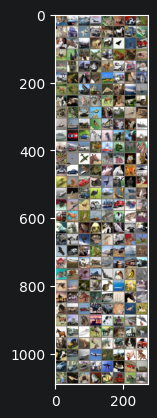

GroundTruth:  cat   ship  ship  plane


In [19]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# print images
imshow(torchvision.utils.make_grid(images.to('cpu')))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [20]:
clsifer = Classifier()
clsifer.load_state_dict(torch.load(PATH, weights_only=True))
clsifer.to(device)
clsifer.eval()

Classifier(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, aff

In [21]:
outputs = clsifer(images)

In [22]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))

Predicted:  cat   ship  car   plane


In [23]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        # calculate outputs by running images through the network
        outputs = clsifer(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 95 %


In [24]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = clsifer(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 96.1 %
Accuracy for class: car   is 98.5 %
Accuracy for class: bird  is 94.6 %
Accuracy for class: cat   is 89.0 %
Accuracy for class: deer  is 97.0 %
Accuracy for class: dog   is 92.6 %
Accuracy for class: frog  is 97.2 %
Accuracy for class: horse is 97.2 %
Accuracy for class: ship  is 97.4 %
Accuracy for class: truck is 96.7 %
